In [ ]:
from google.colab import drive

drive.mount('/content/drive')

print("Google Drive berhasil di-mount!")

Mounted at /content/drive
Google Drive berhasil di-mount!


In [ ]:
!pip install timm albumentations scikit-learn pandas opencv-python-headless

In [ ]:
# -*- coding: utf-8 -*-
"""
=============================================================================
  DIABETIC RETINOPATHY GRADING - FULL PIPELINE
  Architecture: Swin Transformer V2 + 5-Fold Stratified Cross Validation
  Metrics: QWK, F1, Accuracy, Precision, Recall
=============================================================================
  Sesuai Architecture Diagram:
  1. Input Dataset (Train Images)
  2. Image Preprocessing  (BGR→RGB, Crop, Resize 256x256, Ben Graham)
  3. Image Caching        (Load all to RAM)
  4. Data Augmentation    (Train: Flip/Rotate/Color | Val: Normalize only)
  5. Cross Validation     (Stratified 5-Fold, 80:20)
  6. Model Architecture   (SwinV2 Backbone + Regression Head)
  7. Regression Training  (SmoothL1 Loss, AdamW, AMP FP16)
  8. Optimized Thresholding (Score → Class 0-4)
  9. Model Evaluation     (QWK + F1 + Accuracy + Precision + Recall)
=============================================================================
=============================================================================
"""

# ─────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    cohen_kappa_score,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)
import warnings
import gc
from functools import partial
import scipy

warnings.filterwarnings('ignore')


# ─────────────────────────────────────────────
# (0) KONFIGURASI UTAMA
# ─────────────────────────────────────────────
CONFIG = {
    'seed'              : 42,
    'img_size'          : 256,
    'epochs'            : 15,
    'train_batch_size'  : 16,
    'valid_batch_size'  : 32,
    'lr'                : 1e-4,
    'weight_decay'      : 1e-6,
    'accum_steps'       : 2,
    'n_folds'           : 5,           # Stratified 5-Fold
    'model_name'        : 'swinv2_base_window16_256',
    'num_classes'       : 1,           # Regression output (continuous score)
    'device'            : torch.device("cuda:0" if torch.cuda.is_available() else "cpu"),
    'train_dir'         : '/content/drive/MyDrive/Diabetic_Retinopathy/dataset/train_images',
    'csv_path'          : '/content/drive/MyDrive/Diabetic_Retinopathy/dataset/train.csv',
    'save_dir'          : '/content/drive/MyDrive/Diabetic_Retinopathy/saved_models',
    'num_dr_classes'    : 5,           # DR Grade: 0=No DR, 1=Mild, 2=Moderate, 3=Severe, 4=Proliferative
}

DR_CLASS_NAMES = ['No DR (0)', 'Mild (1)', 'Moderate (2)', 'Severe (3)', 'Proliferative (4)']


def seed_everything(seed):
    """Reproducibility lock"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CONFIG['seed'])


# ─────────────────────────────────────────────
# (A) PREPROCESSING KHUSUS MEDIS
#     Diagram Step 2: BGR→RGB, Crop, Resize 256x256, Ben Graham Enhance
# ─────────────────────────────────────────────
def crop_image_from_gray(img, tol=7):
    """
    Step 2 - Crop: Buang border hitam dominan pada gambar fundus retina.
    Piksel dengan nilai <= tol dianggap background gelap dan dipotong.
    """
    if img.ndim == 2:
        mask = img > tol
        return img[np.ix_(mask.any(1), mask.any(0))]
    elif img.ndim == 3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray_img > tol
        check_shape = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))].shape[0]
        if check_shape == 0:
            return img
        img1 = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))]
        img2 = img[:, :, 1][np.ix_(mask.any(1), mask.any(0))]
        img3 = img[:, :, 2][np.ix_(mask.any(1), mask.any(0))]
        return np.stack([img1, img2, img3], axis=-1)
    return img


def ben_color_preprocessing(image, sigmaX=10):
    """
    Step 2 - Ben Graham's Preprocessing:
      1. BGR → RGB (Step 2 diagram: Convert Color)
      2. Crop black border (Step 2 diagram: Crop Image)
      3. Resize to 256×256 (Step 2 diagram: Resize Image)
      4. Gaussian local normalization = enhance contrast retina (Step 2 diagram: Enhance Contrast)
         Formula: result = 4*img - 4*GaussianBlur(img) + 128
         Ini menghilangkan global lighting variasi & menonjolkan pembuluh darah
    """
    # Step 1: BGR → RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    # Step 2: Crop border hitam
    image = crop_image_from_gray(image)
    # Step 3: Resize 256x256
    image = cv2.resize(image, (CONFIG['img_size'], CONFIG['img_size']))
    # Step 4: Ben Graham contrast enhancement
    image = cv2.addWeighted(
        image, 4,
        cv2.GaussianBlur(image, (0, 0), sigmaX), -4,
        128
    )
    return image


# ─────────────────────────────────────────────
# (B) GLOBAL RAM CACHE
#     Diagram Step 3: Save Images to RAM → Faster Data Loading
# ─────────────────────────────────────────────
GLOBAL_IMAGE_CACHE = {}


def load_all_images_to_ram(df, folder_path):
    """
    Step 3 - Image Caching:
    Semua gambar di-preprocess & disimpan ke RAM di awal training.
    Ini bypass lambatnya Google Drive I/O berulang setiap epoch.
    """
    print(f"\n{'='*60}")
    print(f"[STEP 3] MENYEDOT {len(df)} GAMBAR KE RAM...")
    print(f"Folder: {folder_path}")
    print(f"{'='*60}")

    failed_count = 0
    for idx, row in df.iterrows():
        id_code = str(row['id_code'])

        # Coba berbagai ekstensi file
        img_path = None
        for ext in ['.png', '.jpg', '.jpeg', '']:
            candidate = os.path.join(folder_path, f"{id_code}{ext}")
            if os.path.exists(candidate):
                img_path = candidate
                break

        if img_path is None:
            print(f"  ⚠️  Gambar tidak ditemukan: {id_code}")
            failed_count += 1
            continue

        image = cv2.imread(img_path)
        if image is None:
            print(f"  ⚠️  Gagal membaca: {img_path}")
            failed_count += 1
            continue

        GLOBAL_IMAGE_CACHE[id_code] = ben_color_preprocessing(image)

        if (idx + 1) % 500 == 0 or (idx + 1) == len(df):
            print(f"  ✅ Selesai: {idx + 1}/{len(df)} gambar | Cache size: {len(GLOBAL_IMAGE_CACHE)}")

    print(f"\n[STEP 3] SELESAI: {len(GLOBAL_IMAGE_CACHE)} gambar di RAM | {failed_count} gagal")
    print(f"{'='*60}\n")


# ─────────────────────────────────────────────
# (C) DATASET CLASS
# ─────────────────────────────────────────────
class DRDataset(Dataset):
    """
    Dataset yang ambil gambar dari GLOBAL_IMAGE_CACHE (RAM),
    bukan dari disk setiap kali dipanggil → Super cepat!
    """
    def __init__(self, df, transforms=None):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        id_code = str(self.df.iloc[idx]['id_code'])

        # Ambil dari RAM cache
        image = GLOBAL_IMAGE_CACHE.get(id_code)
        if image is None:
            # Fallback: buat gambar hitam jika tidak ada di cache
            image = np.zeros((CONFIG['img_size'], CONFIG['img_size'], 3), dtype=np.uint8)

        # Pastikan image adalah copy agar augmentasi tidak merusak cache
        image = image.copy()

        if self.transforms:
            augmented = self.transforms(image=image)
            image = augmented['image']

        label = torch.tensor(self.df.iloc[idx]['diagnosis'], dtype=torch.float32)
        return image, label


# ─────────────────────────────────────────────
# (D) AUGMENTASI DATA
#     Diagram Step 4:
#     Training Data  → Random Flip/Rotate/Color/Contrast
#     Validation Data → Basic Preprocessing Only (Normalize + ToTensor)
# ─────────────────────────────────────────────
def get_train_transforms():
    """
    Step 4 - Training Augmentation:
    Flip Horizontal & Vertikal, ShiftScaleRotate, HSV Color Jitter,
    CLAHE (Contrast Limited AHE), CoarseDropout (regularization visual)
    """
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.1,
            scale_limit=0.15,
            rotate_limit=60,
            border_mode=cv2.BORDER_REFLECT,
            p=0.5
        ),
        A.HueSaturationValue(
            hue_shift_limit=0.2,
            sat_shift_limit=0.2,
            val_shift_limit=0.2,
            p=0.5
        ),
        A.CLAHE(clip_limit=4.0, p=0.4),
        A.CoarseDropout(
            max_holes=8,
            max_height=32,
            max_width=32,
            fill_value=0,
            p=0.5
        ),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2(),
    ])


def get_valid_transforms():
    """
    Step 4 - Validation: Basic preprocessing only (No augmentation)
    Hanya Normalize dan ToTensor
    """
    return A.Compose([
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2(),
    ])


# ─────────────────────────────────────────────
# (E) MODEL ARSITEKTUR
#     Diagram Step 6: Swin Transformer V2 Backbone + Regression Head
# ─────────────────────────────────────────────
class DRSwinV2Model(nn.Module):
    """
    Step 6 - Model Architecture:

    Backbone: SwinV2-Base (swinv2_base_window16_256)
      - Pretrained ImageNet weights
      - Hierarchical feature extraction via shifted windows
      - Output: feature vector [batch, num_features]

    Regression Head:
      - Dropout(0.3)          → Regularization (cegah overfitting)
      - Linear(features, 512) → Feature Reduction
      - SiLU()                → Non-linear Activation (Swish)
      - Linear(512, 1)        → Continuous Severity Score output

    Note: Pakai regression (bukan classification) karena label DR
    bersifat ordinal (0<1<2<3<4), sehingga urutan penting.
    """
    def __init__(self, pretrained=True):
        super().__init__()

        # Load Swin Transformer V2 backbone
        # num_classes=0 → remove default classification head, kita bikin custom
        self.backbone = timm.create_model(
            CONFIG['model_name'],
            pretrained=pretrained,
            num_classes=0,          # Remove classifier head
            global_pool='avg'       # Global Average Pooling setelah backbone
        )

        in_features = self.backbone.num_features
        print(f"  [Model] Backbone: {CONFIG['model_name']}")
        print(f"  [Model] Feature dim dari backbone: {in_features}")

        # Custom Regression Head
        self.head = nn.Sequential(
            nn.Dropout(p=0.3),                   # Regularization
            nn.Linear(in_features, 512),          # Feature Reduction
            nn.SiLU(),                            # Non-linear Activation (Swish)
            nn.Linear(512, CONFIG['num_classes']) # Output: 1 continuous score
        )

        # Weight initialization untuk head
        self._init_weights()

    def _init_weights(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        # Extract features via SwinV2 backbone
        features = self.backbone(x)    # [B, num_features]
        # Regression head → continuous severity score
        output = self.head(features)   # [B, 1]
        return output.squeeze(1)       # [B] → scalar per sample


# ─────────────────────────────────────────────
# (F) OPTIMIZED THRESHOLDING (Post-processing)
#     Diagram Step 8: Score-to-Class Conversion
#     Continuous Score → Optimized Threshold → DR Class 0-4
# ─────────────────────────────────────────────
class OptimizedRounder:
    """
    Step 8 - Optimized Thresholding:
    Cari threshold terbaik [t0, t1, t2, t3] untuk mapping
    continuous score → discrete DR class (0, 1, 2, 3, 4)
    menggunakan Nelder-Mead optimization untuk maximize QWK.

    Score < t0         → Class 0 (No DR)
    t0 <= score < t1   → Class 1 (Mild)
    t1 <= score < t2   → Class 2 (Moderate)
    t2 <= score < t3   → Class 3 (Severe)
    score >= t3        → Class 4 (Proliferative)
    """
    def __init__(self):
        self.coef_ = [0.5, 1.5, 2.5, 3.5]  # default thresholds

    def _kappa_loss(self, coef, X, y):
        """Negative QWK (untuk minimization)"""
        X_p = self._apply_threshold(X, coef)
        return -cohen_kappa_score(y, X_p, weights='quadratic')

    def _apply_threshold(self, X, coef):
        """Terapkan threshold ke array score"""
        X_p = np.copy(X)
        for i, pred in enumerate(X_p):
            if pred < coef[0]:
                X_p[i] = 0
            elif pred < coef[1]:
                X_p[i] = 1
            elif pred < coef[2]:
                X_p[i] = 2
            elif pred < coef[3]:
                X_p[i] = 3
            else:
                X_p[i] = 4
        return X_p.astype(int)

    def fit(self, X, y):
        """Optimize threshold menggunakan Nelder-Mead"""
        loss_fn = partial(self._kappa_loss, X=X, y=y)
        result = scipy.optimize.minimize(
            loss_fn,
            x0=self.coef_,
            method='nelder-mead',
            options={'xatol': 1e-5, 'fatol': 1e-5, 'maxiter': 10000}
        )
        self.coef_ = result['x'].tolist()
        return self.coef_

    def predict(self, X, coef=None):
        """Prediksi kelas DR dari continuous score"""
        if coef is None:
            coef = self.coef_
        return self._apply_threshold(X, coef)


# ─────────────────────────────────────────────
# (G) METRIC EVALUATOR
#     Diagram Step 9: QWK + F1 + Accuracy + Precision + Recall
# ─────────────────────────────────────────────
def compute_all_metrics(y_true, y_pred, fold=None, epoch=None, verbose=True):
    """
    Step 9 - Model Evaluation:
    Hitung semua metrics:
      1. QWK  - Quadratic Weighted Kappa (metrik utama DR grading)
      2. Accuracy  - % prediksi benar
      3. F1 Score  - Weighted F1 (handle class imbalance)
      4. Precision - Weighted Precision
      5. Recall    - Weighted Recall
    """
    y_true = np.array(y_true).astype(int)
    y_pred = np.array(y_pred).astype(int)

    # Clamp prediksi ke range valid [0, 4]
    y_pred = np.clip(y_pred, 0, 4)

    qwk       = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    accuracy  = accuracy_score(y_true, y_pred)
    f1        = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(y_true, y_pred, average='weighted', zero_division=0)

    metrics = {
        'qwk'      : qwk,
        'accuracy' : accuracy,
        'f1'       : f1,
        'precision': precision,
        'recall'   : recall,
    }

    if verbose:
        prefix = ""
        if fold is not None and epoch is not None:
            prefix = f"[Fold {fold} | Epoch {epoch:02d}] "
        elif fold is not None:
            prefix = f"[Fold {fold}] "

        print(f"{prefix}"
              f"QWK: {qwk:.4f} | "
              f"Acc: {accuracy:.4f} | "
              f"F1: {f1:.4f} | "
              f"Prec: {precision:.4f} | "
              f"Rec: {recall:.4f}")

    return metrics


def print_fold_summary(fold, best_metrics):
    """Print ringkasan per fold"""
    print(f"\n{'─'*60}")
    print(f"  ✅ FOLD {fold} SELESAI - BEST METRICS:")
    print(f"  {'─'*50}")
    print(f"  QWK (Quadratic Weighted Kappa) : {best_metrics['qwk']:.4f}")
    print(f"  Accuracy                       : {best_metrics['accuracy']:.4f} ({best_metrics['accuracy']*100:.2f}%)")
    print(f"  F1 Score (Weighted)            : {best_metrics['f1']:.4f}")
    print(f"  Precision (Weighted)           : {best_metrics['precision']:.4f}")
    print(f"  Recall (Weighted)              : {best_metrics['recall']:.4f}")
    print(f"{'─'*60}\n")


def print_final_summary(fold_results):
    """Print ringkasan akhir semua fold + rata-rata"""
    print(f"\n{'='*65}")
    print(f"  🏆 HASIL AKHIR 5-FOLD CROSS VALIDATION")
    print(f"{'='*65}")

    metric_names = ['qwk', 'accuracy', 'f1', 'precision', 'recall']
    metric_labels = {
        'qwk'      : 'QWK (Quadratic Weighted Kappa)',
        'accuracy' : 'Accuracy',
        'f1'       : 'F1 Score (Weighted)',
        'precision': 'Precision (Weighted)',
        'recall'   : 'Recall (Weighted)',
    }

    for metric in metric_names:
        values = [r[metric] for r in fold_results]
        mean_val = np.mean(values)
        std_val  = np.std(values)
        fold_str = " | ".join([f"F{i+1}: {v:.4f}" for i, v in enumerate(values)])
        print(f"\n  📊 {metric_labels[metric]}")
        print(f"     Per-Fold: {fold_str}")
        print(f"     Mean ± Std: {mean_val:.4f} ± {std_val:.4f}")

    print(f"\n{'='*65}")
    print(f"  📌 OOF QWK Score (Cross-Validation): {np.mean([r['qwk'] for r in fold_results]):.4f}")
    print(f"{'='*65}\n")


# ─────────────────────────────────────────────
# (H) TRAINING LOOP
#     Diagram Step 7: SmoothL1 Loss + AdamW + AMP FP16
# ─────────────────────────────────────────────
def train_one_epoch(model, dataloader, optimizer, criterion, scaler):
    """
    Step 7 - Regression Training (satu epoch):
    - SmoothL1 Loss (Huber Loss): robust terhadap outlier, cocok untuk ordinal regression
    - AdamW Optimizer: weight decay decoupled, lebih stabil dari Adam
    - Automatic Mixed Precision (FP16): hemat memori GPU, training lebih cepat
    - Gradient Accumulation: simulate larger batch size
    """
    model.train()
    running_loss = 0.0
    optimizer.zero_grad()

    for step, (images, targets) in enumerate(dataloader):
        images  = images.to(CONFIG['device'])
        targets = targets.to(CONFIG['device'])

        # AMP FP16 forward pass
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, targets)
            loss = loss / CONFIG['accum_steps']  # Normalize untuk gradient accumulation

        # AMP backward pass
        scaler.scale(loss).backward()

        # Gradient accumulation step
        if (step + 1) % CONFIG['accum_steps'] == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        running_loss += loss.item() * CONFIG['accum_steps']

    # Handle sisa step yang belum di-update
    if (len(dataloader)) % CONFIG['accum_steps'] != 0:
        scaler.unscale_(optimizer)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

    torch.cuda.empty_cache()
    return running_loss / len(dataloader)


@torch.no_grad()
def validate_one_epoch(model, dataloader):
    """Validasi: kumpulkan semua prediksi & target"""
    model.eval()
    all_preds   = []
    all_targets = []

    for images, targets in dataloader:
        images = images.to(CONFIG['device'])
        outputs = model(images)
        all_preds.extend(outputs.cpu().numpy().tolist())
        all_targets.extend(targets.numpy().tolist())

    return np.array(all_preds), np.array(all_targets)


# ─────────────────────────────────────────────
# (I) MAIN K-FOLD TRAINING
#     Diagram Step 5: Stratified 5-Fold Cross Validation
# ─────────────────────────────────────────────
def run_kfold_training(train_df):
    """
    Full pipeline sesuai architecture diagram:
    Step 1 → Step 2 → Step 3 → Step 4 → Step 5 → Step 6 → Step 7 → Step 8 → Step 9
    """

    # Step 3: Load semua gambar ke RAM
    load_all_images_to_ram(train_df, CONFIG['train_dir'])

    # Buat folder untuk save model
    os.makedirs(CONFIG['save_dir'], exist_ok=True)

    # Step 5: Stratified 5-Fold (jaga distribusi kelas setiap fold)
    skf = StratifiedKFold(
        n_splits=CONFIG['n_folds'],
        shuffle=True,
        random_state=CONFIG['seed']
    )

    fold_results = []  # Simpan best metrics setiap fold

    print(f"\n{'='*65}")
    print(f"  🚀 MEMULAI 5-FOLD CROSS VALIDATION")
    print(f"  Device : {CONFIG['device']}")
    print(f"  Model  : {CONFIG['model_name']}")
    print(f"  Epochs : {CONFIG['epochs']}")
    print(f"  Data   : {len(train_df)} samples")
    print(f"{'='*65}")

    for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, train_df['diagnosis']), start=1):

        print(f"\n{'🔥'*5} FOLD {fold}/{CONFIG['n_folds']} {'🔥'*5}")
        print(f"  Train: {len(train_idx)} samples | Val: {len(val_idx)} samples")

        # Split data
        train_data = train_df.iloc[train_idx].reset_index(drop=True)
        val_data   = train_df.iloc[val_idx].reset_index(drop=True)

        # Step 4: Dataset + Augmentasi
        train_dataset = DRDataset(train_data, transforms=get_train_transforms())
        val_dataset   = DRDataset(val_data,   transforms=get_valid_transforms())

        train_loader = DataLoader(
            train_dataset,
            batch_size=CONFIG['train_batch_size'],
            shuffle=True,
            num_workers=2,
            pin_memory=True,
            drop_last=True
        )
        val_loader = DataLoader(
            val_dataset,
            batch_size=CONFIG['valid_batch_size'],
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )

        # Step 6: Inisialisasi model
        print(f"\n  [Step 6] Inisialisasi SwinV2 Model...")
        model = DRSwinV2Model(pretrained=True).to(CONFIG['device'])

        # Step 7: Loss, Optimizer, Scheduler, Scaler
        criterion = nn.SmoothL1Loss()          # Huber Loss for ordinal regression
        optimizer = optim.AdamW(
            model.parameters(),
            lr=CONFIG['lr'],
            weight_decay=CONFIG['weight_decay']
        )
        # Cosine Annealing LR Scheduler
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=CONFIG['epochs'],
            eta_min=1e-6
        )
        scaler = GradScaler()

        best_qwk      = -np.inf
        best_metrics  = None
        best_model_path = os.path.join(CONFIG['save_dir'], f'swinv2_best_fold{fold}.pth')

        print(f"  [Step 7] Mulai Training {CONFIG['epochs']} Epoch...\n")

        for epoch in range(1, CONFIG['epochs'] + 1):

            # Training epoch
            train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler)

            # Validation epoch
            val_preds, val_targets = validate_one_epoch(model, val_loader)

            # Step 8: Optimized Thresholding (Score → Class)
            optR = OptimizedRounder()
            optR.fit(val_preds, val_targets)
            val_preds_class = optR.predict(val_preds)

            # Step 9: Hitung semua metrics
            metrics = compute_all_metrics(
                val_targets, val_preds_class,
                fold=fold, epoch=epoch, verbose=False
            )

            # Print semua metrics per epoch
            print(f"  Fold {fold} | Ep {epoch:02d}/{CONFIG['epochs']} | "
                  f"Loss: {train_loss:.4f} | "
                  f"QWK: {metrics['qwk']:.4f} | "
                  f"Acc: {metrics['accuracy']:.4f} | "
                  f"F1: {metrics['f1']:.4f} | "
                  f"Prec: {metrics['precision']:.4f} | "
                  f"Rec: {metrics['recall']:.4f}")

            # Simpan model terbaik berdasarkan QWK
            if metrics['qwk'] > best_qwk:
                best_qwk     = metrics['qwk']
                best_metrics = metrics.copy()
                best_metrics['thresholds'] = optR.coef_

                torch.save({
                    'epoch'           : epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state' : optimizer.state_dict(),
                    'metrics'         : best_metrics,
                    'thresholds'      : optR.coef_,
                    'config'          : CONFIG,
                }, best_model_path)

                print(f"  {'⭐'*3} NEW BEST QWK: {best_qwk:.4f} "
                      f"| Threshold: {[round(t, 3) for t in optR.coef_]} "
                      f"| Model saved!")

            scheduler.step()

        # Print fold summary
        print_fold_summary(fold, best_metrics)
        fold_results.append(best_metrics)

        # Clean-up GPU memory antar fold
        del model, train_loader, val_loader, train_dataset, val_dataset
        del optimizer, scheduler, scaler
        gc.collect()
        torch.cuda.empty_cache()

    # Print final summary semua fold
    print_final_summary(fold_results)

    return fold_results


# ─────────────────────────────────────────────
# (J) INFERENCE / PREDICTION (opsional)
# ─────────────────────────────────────────────
def predict_single_image(image_path, model_path, threshold_coef=None):
    """
    Prediksi DR grade untuk satu gambar menggunakan model terbaik.
    Returns: (predicted_class, raw_score, class_name)
    """
    # Load & preprocess gambar
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Gambar tidak ditemukan: {image_path}")

    image = ben_color_preprocessing(image)

    # Apply valid transforms
    transform = get_valid_transforms()
    image_tensor = transform(image=image)['image']
    image_tensor = image_tensor.unsqueeze(0).to(CONFIG['device'])  # [1, C, H, W]

    # Load model
    model = DRSwinV2Model(pretrained=False).to(CONFIG['device'])
    checkpoint = torch.load(model_path, map_location=CONFIG['device'])
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    # Prediksi
    with torch.no_grad():
        raw_score = model(image_tensor).item()

    # Apply threshold
    if threshold_coef is None:
        threshold_coef = checkpoint.get('thresholds', [0.5, 1.5, 2.5, 3.5])

    optR = OptimizedRounder()
    optR.coef_ = threshold_coef
    pred_class = int(optR.predict(np.array([raw_score]))[0])

    class_name = DR_CLASS_NAMES[pred_class]
    print(f"  Raw Score  : {raw_score:.4f}")
    print(f"  Thresholds : {[round(t, 3) for t in threshold_coef]}")
    print(f"  DR Grade   : {pred_class} ({class_name})")

    return pred_class, raw_score, class_name


def ensemble_predict(image_path, model_paths_and_thresholds):
    """
    Ensemble prediction dari 5 model fold (rata-rata score, lalu threshold).
    """
    transform = get_valid_transforms()

    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Gambar tidak ditemukan: {image_path}")

    image = ben_color_preprocessing(image)
    image_tensor = transform(image=image)['image'].unsqueeze(0).to(CONFIG['device'])

    all_scores = []

    for fold_num, (model_path, threshold_coef) in enumerate(model_paths_and_thresholds, start=1):
        model = DRSwinV2Model(pretrained=False).to(CONFIG['device'])
        checkpoint = torch.load(model_path, map_location=CONFIG['device'])
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()

        with torch.no_grad():
            score = model(image_tensor).item()
        all_scores.append(score)

        del model
        gc.collect()
        torch.cuda.empty_cache()

    # Ensemble: rata-rata score
    ensemble_score = np.mean(all_scores)
    print(f"  Per-Fold Scores: {[round(s, 4) for s in all_scores]}")
    print(f"  Ensemble Score : {ensemble_score:.4f}")

    # Gunakan threshold dari fold terakhir (atau bisa di-average juga)
    avg_thresholds = np.mean([t for _, t in model_paths_and_thresholds], axis=0).tolist()
    optR = OptimizedRounder()
    pred_class = int(optR.predict(np.array([ensemble_score]), coef=avg_thresholds)[0])

    class_name = DR_CLASS_NAMES[pred_class]
    print(f"  Ensemble DR Grade: {pred_class} ({class_name})")

    return pred_class, ensemble_score, class_name


# ─────────────────────────────────────────────
# (K) MAIN ENTRY POINT
# ─────────────────────────────────────────────
if __name__ == '__main__':

    print("=" * 65)
    print("  DIABETIC RETINOPATHY GRADING - SWIN TRANSFORMER V2")
    print("  Pipeline: Preprocessing → Caching → 5-Fold CV → Eval")
    print("=" * 65)

    # ────────────────────────────────────────
    # SEBELUM JALANKAN, INSTALL INI DI COLAB:
    # ────────────────────────────────────────
    # !pip install timm albumentations scikit-learn pandas opencv-python-headless scipy

    # Mount Google Drive
    # from google.colab import drive
    # drive.mount('/content/drive')
    # ────────────────────────────────────────

    csv_path = CONFIG['csv_path']

    try:
        print(f"\n[STEP 1] INPUT DATASET")
        print(f"  Membaca CSV dari: {csv_path}")
        df_train = pd.read_csv(csv_path)

        print(f"  Total sampel   : {len(df_train)}")
        print(f"  Kolom          : {df_train.columns.tolist()}")
        print(f"\n  Distribusi label (DR Grade):")
        for grade, count in sorted(df_train['diagnosis'].value_counts().items()):
            pct = count / len(df_train) * 100
            bar = '█' * int(pct / 2)
            name = DR_CLASS_NAMES[int(grade)]
            print(f"    Grade {int(grade)} ({name:20s}): {count:5d} ({pct:5.1f}%) {bar}")

        # Validasi kolom
        required_cols = ['id_code', 'diagnosis']
        for col in required_cols:
            if col not in df_train.columns:
                raise ValueError(f"Kolom '{col}' tidak ditemukan di CSV! "
                                 f"Kolom tersedia: {df_train.columns.tolist()}")

        # Pastikan diagnosis adalah integer
        df_train['diagnosis'] = df_train['diagnosis'].astype(int)

        # ────────────────────────────────────
        # GAS K-FOLD TRAINING!
        # ────────────────────────────────────
        fold_results = run_kfold_training(df_train)

        # Simpan summary hasil ke CSV
        summary_df = pd.DataFrame(fold_results)
        summary_df.index = [f'Fold {i+1}' for i in range(len(fold_results))]
        summary_path = os.path.join(CONFIG['save_dir'], 'training_summary.csv')
        summary_df.to_csv(summary_path)
        print(f"\n✅ Training summary disimpan ke: {summary_path}")

        print("\n🎉 TRAINING SELESAI! Model tersimpan di:")
        for i in range(1, CONFIG['n_folds'] + 1):
            path = os.path.join(CONFIG['save_dir'], f'swinv2_best_fold{i}.pth')
            print(f"   Fold {i}: {path}")

    except FileNotFoundError as e:
        print(f"\n❌ FILE TIDAK DITEMUKAN: {e}")
        print("   Pastikan path CSV dan folder gambar sudah benar di CONFIG!")
    except ValueError as e:
        print(f"\n❌ ERROR DATA: {e}")
    except Exception as e:
        print(f"\n❌ UNEXPECTED ERROR: {e}")
        import traceback
        traceback.print_exc()

  DIABETIC RETINOPATHY GRADING - SWIN TRANSFORMER V2
  Pipeline: Preprocessing → Caching → 5-Fold CV → Eval

[STEP 1] INPUT DATASET
  Membaca CSV dari: /content/drive/MyDrive/Diabetic_Retinopathy/dataset/train.csv
  Total sampel   : 3662
  Kolom          : ['id_code', 'diagnosis']

  Distribusi label (DR Grade):
    Grade 0 (No DR (0)           ):  1805 ( 49.3%) ████████████████████████
    Grade 1 (Mild (1)            ):   370 ( 10.1%) █████
    Grade 2 (Moderate (2)        ):   999 ( 27.3%) █████████████
    Grade 3 (Severe (3)          ):   193 (  5.3%) ██
    Grade 4 (Proliferative (4)   ):   295 (  8.1%) ████

[STEP 3] MENYEDOT 3662 GAMBAR KE RAM...
Folder: /content/drive/MyDrive/Diabetic_Retinopathy/dataset/train_images
  ✅ Selesai: 500/3662 gambar | Cache size: 500
  ✅ Selesai: 1000/3662 gambar | Cache size: 1000
  ✅ Selesai: 1500/3662 gambar | Cache size: 1500
  ✅ Selesai: 2000/3662 gambar | Cache size: 2000
  ✅ Selesai: 2500/3662 gambar | Cache size: 2500
  ✅ Selesai: 3000/366

model.safetensors:   0%|          | 0.00/357M [00:00<?, ?B/s]

  [Model] Backbone: swinv2_base_window16_256
  [Model] Feature dim dari backbone: 1024
  [Step 7] Mulai Training 15 Epoch...

  Fold 1 | Ep 01/15 | Loss: 0.2681 | QWK: 0.9023 | Acc: 0.7353 | F1: 0.7400 | Prec: 0.7844 | Rec: 0.7353
  ⭐⭐⭐ NEW BEST QWK: 0.9023 | Threshold: [0.526, 1.681, 2.365, 3.175] | Model saved!
  Fold 1 | Ep 02/15 | Loss: 0.1546 | QWK: 0.8997 | Acc: 0.7462 | F1: 0.7473 | Prec: 0.8079 | Rec: 0.7462
  Fold 1 | Ep 03/15 | Loss: 0.1369 | QWK: 0.9199 | Acc: 0.8131 | F1: 0.8132 | Prec: 0.8354 | Rec: 0.8131
  ⭐⭐⭐ NEW BEST QWK: 0.9199 | Threshold: [0.532, 1.647, 2.374, 3.166] | Model saved!
  Fold 1 | Ep 04/15 | Loss: 0.1221 | QWK: 0.9245 | Acc: 0.7954 | F1: 0.8064 | Prec: 0.8362 | Rec: 0.7954
  ⭐⭐⭐ NEW BEST QWK: 0.9245 | Threshold: [0.505, 1.567, 2.376, 3.576] | Model saved!
  Fold 1 | Ep 05/15 | Loss: 0.1058 | QWK: 0.9301 | Acc: 0.8104 | F1: 0.8241 | Prec: 0.8545 | Rec: 0.8104
  ⭐⭐⭐ NEW BEST QWK: 0.9301 | Threshold: [0.516, 1.592, 2.241, 3.538] | Model saved!
  Fold 1 | Ep

In [ ]:
# =========================================================
# LOAD SAVED MODEL + MATRIX EVALUATION
# SwinV2 Diabetic Retinopathy - 5 Fold Evaluation
# =========================================================

from google.colab import drive
drive.mount('/content/drive')

!pip install timm albumentations scikit-learn pandas opencv-python-headless scipy -q

import os
import gc
import cv2
import timm
import torch
import random
import warnings
import numpy as np
import pandas as pd
import torch.nn as nn
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    cohen_kappa_score,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")


# =========================================================
# 1. CONFIG - SAMA DENGAN TRAINING
# =========================================================

CONFIG = {
    'seed'              : 42,
    'img_size'          : 256,
    'valid_batch_size'  : 32,
    'n_folds'           : 5,
    'model_name'        : 'swinv2_base_window16_256',
    'num_classes'       : 1,
    'device'            : torch.device("cuda:0" if torch.cuda.is_available() else "cpu"),

    # Sesuaikan kalau path kamu beda
    'train_dir'         : '/content/drive/MyDrive/Diabetic_Retinopathy/dataset/train_images',
    'csv_path'          : '/content/drive/MyDrive/Diabetic_Retinopathy/dataset/train.csv',
    'save_dir'          : '/content/drive/MyDrive/Diabetic_Retinopathy/saved_models',
}

DR_CLASS_NAMES = [
    'No DR (0)',
    'Mild (1)',
    'Moderate (2)',
    'Severe (3)',
    'Proliferative (4)'
]


# =========================================================
# 2. RANDOM SEED - SAMA DENGAN TRAINING
# =========================================================

def seed_everything(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CONFIG['seed'])

print("Device:", CONFIG['device'])
print("Seed  :", CONFIG['seed'])


# =========================================================
# 3. PREPROCESSING - SAMA DENGAN TRAINING
# =========================================================

def crop_image_from_gray(img, tol=7):
    if img.ndim == 2:
        mask = img > tol
        return img[np.ix_(mask.any(1), mask.any(0))]

    elif img.ndim == 3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray_img > tol

        check_shape = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))].shape[0]

        if check_shape == 0:
            return img

        img1 = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))]
        img2 = img[:, :, 1][np.ix_(mask.any(1), mask.any(0))]
        img3 = img[:, :, 2][np.ix_(mask.any(1), mask.any(0))]

        return np.stack([img1, img2, img3], axis=-1)

    return img


def ben_color_preprocessing(image, sigmaX=10):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = crop_image_from_gray(image)
    image = cv2.resize(image, (CONFIG['img_size'], CONFIG['img_size']))

    image = cv2.addWeighted(
        image, 4,
        cv2.GaussianBlur(image, (0, 0), sigmaX), -4,
        128
    )

    return image


def get_valid_transforms():
    return A.Compose([
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2(),
    ])


# =========================================================
# 4. DATASET UNTUK EVALUATION
# =========================================================

class DRDatasetEval(Dataset):
    def __init__(self, df, image_dir, transforms=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        id_code = str(self.df.iloc[idx]['id_code'])
        label = int(self.df.iloc[idx]['diagnosis'])

        img_path = None
        for ext in ['.png', '.jpg', '.jpeg', '']:
            candidate = os.path.join(self.image_dir, f"{id_code}{ext}")
            if os.path.exists(candidate):
                img_path = candidate
                break

        if img_path is None:
            raise FileNotFoundError(f"Gambar tidak ditemukan: {id_code}")

        image = cv2.imread(img_path)

        if image is None:
            raise ValueError(f"Gagal membaca gambar: {img_path}")

        image = ben_color_preprocessing(image)

        if self.transforms:
            image = self.transforms(image=image)['image']

        return image, label


# =========================================================
# 5. MODEL ARCHITECTURE - SAMA DENGAN TRAINING
# =========================================================

class DRSwinV2Model(nn.Module):
    def __init__(self, pretrained=False):
        super().__init__()

        self.backbone = timm.create_model(
            CONFIG['model_name'],
            pretrained=pretrained,
            num_classes=0,
            global_pool='avg'
        )

        in_features = self.backbone.num_features

        self.head = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 512),
            nn.SiLU(),
            nn.Linear(512, CONFIG['num_classes'])
        )

    def forward(self, x):
        features = self.backbone(x)
        output = self.head(features)
        return output.squeeze(1)


# =========================================================
# 6. THRESHOLDING - SAMA DENGAN TRAINING
# =========================================================

def apply_threshold(scores, coef):
    scores = np.array(scores)
    preds = np.zeros_like(scores, dtype=int)

    for i, score in enumerate(scores):
        if score < coef[0]:
            preds[i] = 0
        elif score < coef[1]:
            preds[i] = 1
        elif score < coef[2]:
            preds[i] = 2
        elif score < coef[3]:
            preds[i] = 3
        else:
            preds[i] = 4

    return preds


# =========================================================
# 7. METRICS FUNCTION
# =========================================================

def evaluate_metrics(y_true, y_pred, title="Evaluation"):
    y_true = np.array(y_true).astype(int)
    y_pred = np.array(y_pred).astype(int)
    y_pred = np.clip(y_pred, 0, 4)

    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)

    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)
    print(f"QWK       : {qwk:.5f}")
    print(f"Accuracy  : {acc:.5f}")
    print(f"F1 Score  : {f1:.5f}")
    print(f"Precision : {precision:.5f}")
    print(f"Recall    : {recall:.5f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=DR_CLASS_NAMES,
        digits=4,
        zero_division=0
    ))

    return {
        "qwk": qwk,
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }


# =========================================================
# 8. PREDICT ONE FOLD
# =========================================================

@torch.no_grad()
def predict_fold(model, dataloader):
    model.eval()

    all_scores = []
    all_targets = []

    for images, targets in dataloader:
        images = images.to(CONFIG['device'])

        outputs = model(images)

        all_scores.extend(outputs.detach().cpu().numpy().tolist())
        all_targets.extend(targets.numpy().tolist())

    return np.array(all_scores), np.array(all_targets)


# =========================================================
# 9. MAIN EVALUATION 5-FOLD
# =========================================================

df_train = pd.read_csv(CONFIG['csv_path'])
df_train['diagnosis'] = df_train['diagnosis'].astype(int)

print("Total data:", len(df_train))
print(df_train['diagnosis'].value_counts().sort_index())

skf = StratifiedKFold(
    n_splits=CONFIG['n_folds'],
    shuffle=True,
    random_state=CONFIG['seed']
)

all_oof_true = []
all_oof_pred = []
all_oof_scores = []

fold_results = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(df_train, df_train['diagnosis']),
    start=1
):
    print("\n" + "🔥" * 20)
    print(f"EVALUATING FOLD {fold}")
    print("🔥" * 20)

    val_df = df_train.iloc[val_idx].reset_index(drop=True)

    val_dataset = DRDatasetEval(
        val_df,
        image_dir=CONFIG['train_dir'],
        transforms=get_valid_transforms()
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=CONFIG['valid_batch_size'],
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    model_path = os.path.join(CONFIG['save_dir'], f'swinv2_best_fold{fold}.pth')

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model fold {fold} tidak ditemukan: {model_path}")

    checkpoint = torch.load(
        model_path,
        map_location=CONFIG['device'],
        weights_only=False
    )

    model = DRSwinV2Model(pretrained=False).to(CONFIG['device'])
    model.load_state_dict(checkpoint['model_state_dict'])

    thresholds = checkpoint.get('thresholds', [0.5, 1.5, 2.5, 3.5])

    print(f"Loaded model : {model_path}")
    print(f"Best epoch   : {checkpoint.get('epoch', 'unknown')}")
    print(f"Thresholds   : {[round(t, 4) for t in thresholds]}")

    val_scores, val_targets = predict_fold(model, val_loader)
    val_preds = apply_threshold(val_scores, thresholds)

    metrics = evaluate_metrics(
        val_targets,
        val_preds,
        title=f"Fold {fold} Evaluation"
    )

    metrics['fold'] = fold
    metrics['thresholds'] = thresholds
    fold_results.append(metrics)

    all_oof_true.extend(val_targets.tolist())
    all_oof_pred.extend(val_preds.tolist())
    all_oof_scores.extend(val_scores.tolist())

    del model, val_loader, val_dataset
    gc.collect()
    torch.cuda.empty_cache()


# =========================================================
# 10. FINAL OOF EVALUATION
# =========================================================

oof_metrics = evaluate_metrics(
    all_oof_true,
    all_oof_pred,
    title="FINAL OOF EVALUATION - 5 FOLD COMBINED"
)


# =========================================================
# 11. SAVE RESULT TO CSV
# =========================================================

fold_summary_df = pd.DataFrame(fold_results)

summary_path = os.path.join(CONFIG['save_dir'], 'evaluation_summary_from_saved_models.csv')
fold_summary_df.to_csv(summary_path, index=False)

oof_df = pd.DataFrame({
    'true_label': all_oof_true,
    'raw_score': all_oof_scores,
    'pred_label': all_oof_pred
})

oof_path = os.path.join(CONFIG['save_dir'], 'oof_predictions_from_saved_models.csv')
oof_df.to_csv(oof_path, index=False)

print("\n✅ Evaluation summary saved to:")
print(summary_path)

print("\n✅ OOF predictions saved to:")
print(oof_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda:0
Seed  : 42
Total data: 3662
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
EVALUATING FOLD 1
🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
Loaded model : /content/drive/MyDrive/Diabetic_Retinopathy/saved_models/swinv2_best_fold1.pth
Best epoch   : 13
Thresholds   : [0.5328, 1.4859, 2.3906, 3.4016]

Fold 1 Evaluation
QWK       : 0.93398
Accuracy  : 0.85539
F1 Score  : 0.85424
Precision : 0.85766
Recall    : 0.85539

Confusion Matrix:
[[361   0   0   0   0]
 [  0  43  31   0   0]
 [  0  13 167  18   2]
 [  0   1   9  19  10]
 [  0   0  15   7  37]]

Classification Report:
                   precision    recall  f1-score   support

        No DR (0)     1.0000    1.0000    1.0000       361
         Mild (1)     0.7544    0.5811    0.6565        74
     Moderate (2)     0.7523    0.8350    0.7915       200
      

FileNotFoundError: Model fold 5 tidak ditemukan: /content/drive/MyDrive/Diabetic_Retinopathy/saved_models/swinv2_best_fold5.pth

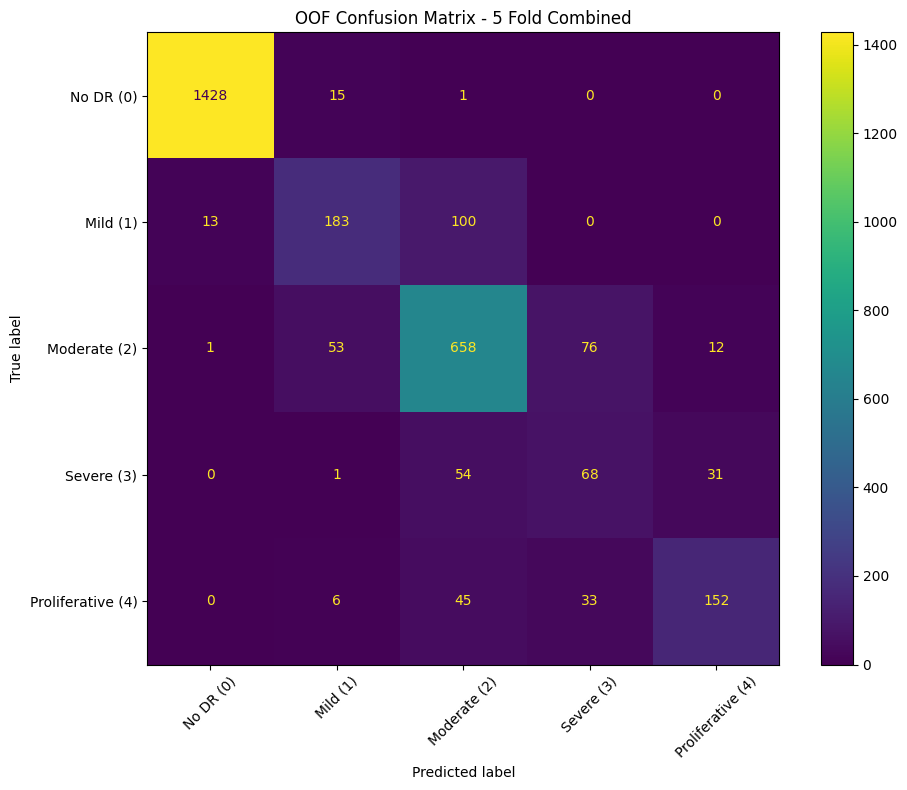

✅ Confusion matrix image saved to:
/content/drive/MyDrive/Diabetic_Retinopathy/saved_models/oof_confusion_matrix.png


In [ ]:
# =========================================================
# OPTIONAL: CONFUSION MATRIX HEATMAP
# =========================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(all_oof_true, all_oof_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=DR_CLASS_NAMES
)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, values_format='d')

plt.title("OOF Confusion Matrix - 5 Fold Combined")
plt.tight_layout()

cm_path = os.path.join(CONFIG['save_dir'], 'oof_confusion_matrix.png')
plt.savefig(cm_path, dpi=300)
plt.show()

print("✅ Confusion matrix image saved to:")
print(cm_path)